In [1]:
## -------------------------------------
## 이미지 데이터 로딩 & 기본 정보
## -------------------------------------
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")

import importlib
import cv_utils

importlib.reload(cv_utils)

<module 'cv_utils' from 'c:\\Users\\82105\\OneDrive\\바탕 화면\\14_ai\\work_0616_이한이\\cv_utils.py'>

In [5]:
# 이미지 임포트


img = cv2.imread('./pill.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
k9 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)) #타원-> ellipse

In [ ]:
# =========================
# 1. 전체 알약 후보 마스크
# =========================
edge = cv2.Canny(blur, 30, 100)

mask = cv2.dilate(edge, k5, iterations=2)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k9, iterations=2) # 팽-> 침

pill_mask = np.zeros_like(gray)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for c in contours:
    if cv2.contourArea(c) > 1000: # 면적이 너무 작으면 노이즈일 가능성
        cv2.drawContours(pill_mask, [c], -1, 255, -1)

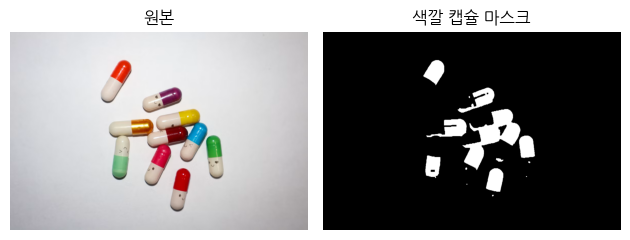

' \n흰색 부분  → 색깔 캡슐\n검은색 부분 → 배경 또는 흰색 캡슐\n'

In [19]:

# =========================
# 2. 색깔 캡슐 영역 추출
# =========================
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

color = cv2.inRange(hsv, np.array([0, 70, 50]), np.array([179, 255, 255]))

# 작은 노이즈 제거
color = cv2.morphologyEx(color, cv2.MORPH_OPEN, k3, iterations=1)

# 빛 반사로 끊긴 유색 부분 연결
color = cv2.morphologyEx(color, cv2.MORPH_CLOSE, k3, iterations=2)

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("원본")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(color, cmap="gray")
plt.title("색깔 캡슐 마스크")
plt.axis("off")

plt.tight_layout()
plt.show()


''' 
흰색 부분  → 색깔 캡슐
검은색 부분 → 배경 또는 흰색 캡슐
'''

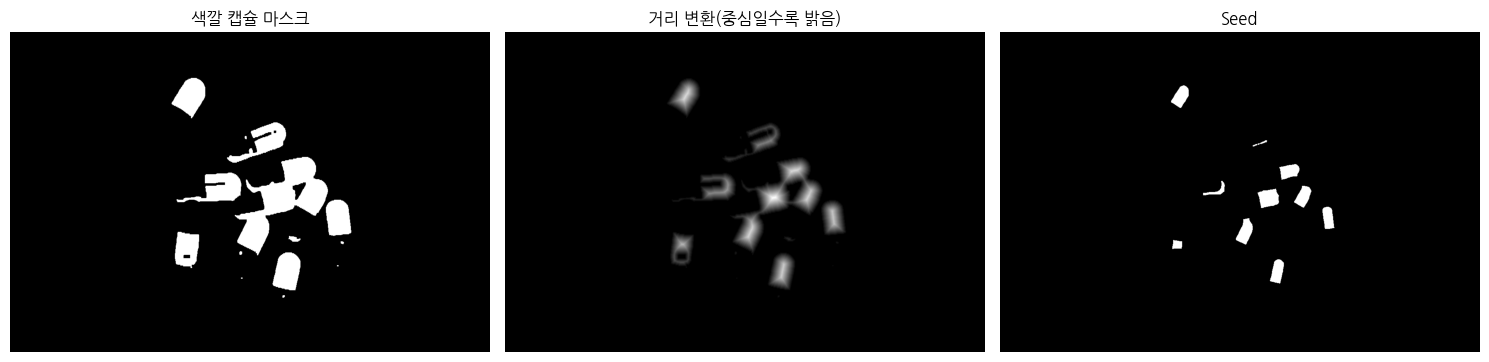

In [ ]:

# =========================
# 3. seed 만들기--> 각 알약의 중심점만 뽑아서 개수 세기
# =========================
dist = cv2.distanceTransform(color, cv2.DIST_L2, 5) 

if dist.max() > 0:
    _, seed = cv2.threshold( dist, 0.45 * dist.max(), 255, cv2.THRESH_BINARY)
else:
    seed = np.zeros_like(gray)

seed = np.uint8(seed)

# seed도 한 번 정리
seed = cv2.morphologyEx(seed, cv2.MORPH_OPEN, k3, iterations=1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(color, cmap="gray")
plt.title("색깔 캡슐 마스크")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(dist, cmap="gray")
plt.title("거리 변환(중심일수록 밝음)") 
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(seed, cmap="gray")
plt.title("Seed")
plt.axis("off")

plt.tight_layout()
plt.show()


검출된 색깔 캡슐 개수: 10


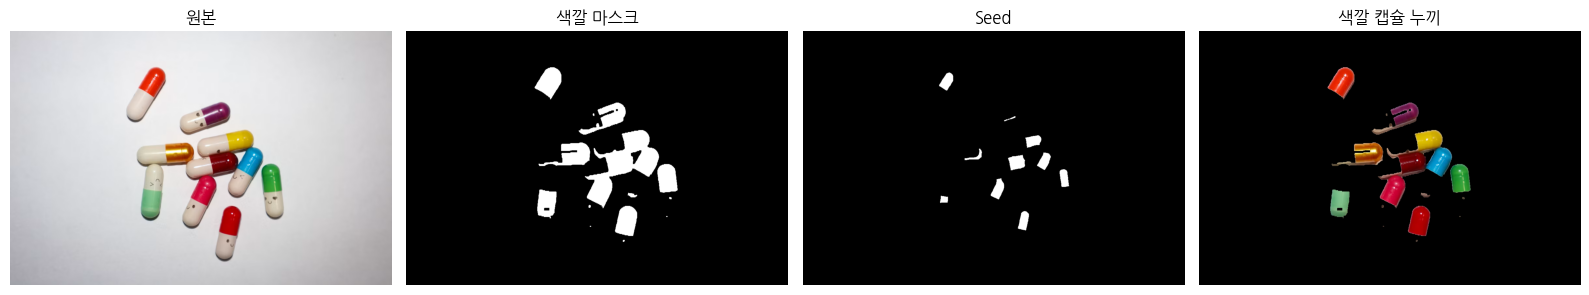

In [23]:
# =========================
# 4. 색깔 캡슐 카운트 + 누끼
# =========================
num, labels, stats, centers = cv2.connectedComponentsWithStats(seed)

result = img_rgb.copy()
nukki = np.zeros_like(img_rgb)

# 색깔 마스크 기준으로 누끼 생성
nukki[color > 0] = img_rgb[color > 0]

count = 0

for i in range(1, num):
    area = stats[i, cv2.CC_STAT_AREA]

    if area < 50:
        continue

    count += 1

    cx, cy = map(int, centers[i])

    cv2.putText( result, str(count), (cx - 10, cy + 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)

print("검출된 색깔 캡슐 개수:", count)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("원본")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(color, cmap="gray")
plt.title("색깔 마스크")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(seed, cmap="gray")
plt.title("Seed")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(nukki)
plt.title("색깔 캡슐 누끼")
plt.axis("off")

plt.tight_layout()
plt.show()

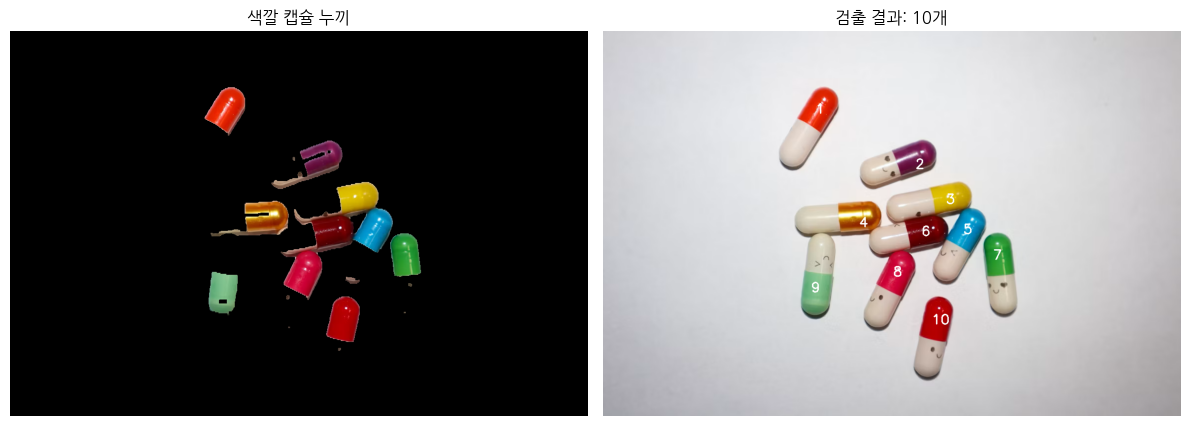

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(nukki)
plt.title("색깔 캡슐 누끼")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title(f"검출 결과: {count}개")
plt.axis("off")

plt.tight_layout()
plt.show()

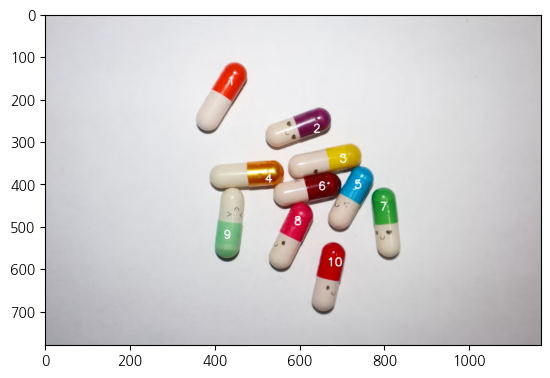

In [26]:
plt.imshow(result)